# SMOTE strategy: 

Create artifical data to balance target classes
we might get good evaluation metrics here, but we have to check the counterfactuals...

## load

In [1]:
import os
from pathlib import Path
import joblib

from dotenv import load_dotenv
import pandas as pd

In [2]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [3]:
train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [4]:
TARGET = "hltprhc"

X_train = train_df.drop(TARGET, axis=1)
y_train = train_df[TARGET]

X_test = test_df.drop(TARGET, axis=1)
y_test = test_df[TARGET]

print(X_train.shape)
print(X_test.shape)

(32883, 8)
(8221, 8)


### SMOTE

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [6]:
import matplotlib.pyplot as plt

def plot_target_distribution(y_before, y_after, label):
    fig, ax = plt.subplots(figsize=(8, 5))

    before_counts = y_before.value_counts().sort_index()
    after_counts = y_after.value_counts().sort_index()

    x = range(len(before_counts))
    width = 0.35

    ax.bar([i - width/2 for i in x], before_counts.values, width, label='Before', alpha=0.8)
    ax.bar([i + width/2 for i in x], after_counts.values, width, label='After', alpha=0.8)

    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.set_xticks(x)
    ax.set_xticklabels(before_counts.index)
    ax.legend()

    plt.tight_layout()
    plt.show()


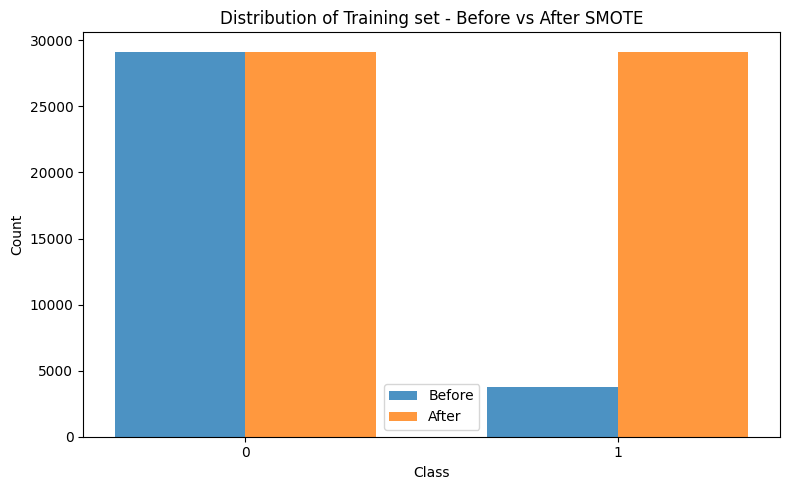

In [7]:
plot_target_distribution(y_train, y_train_res, label="Training set - Before vs After SMOTE")

### Train and evaluate model

In [8]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, n_estimators=300)
model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [9]:
y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      7287
           1       0.18      0.42      0.25       934

    accuracy                           0.71      8221
   macro avg       0.54      0.58      0.54      8221
weighted avg       0.83      0.71      0.76      8221

Roc Score auc score:  0.5848193623974407 



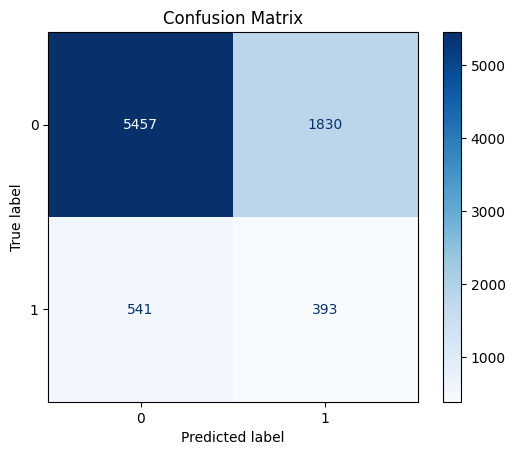

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_test, y_pred))
print("Roc Score auc score: ", roc_auc_score(y_test, y_pred), "\n")


disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [11]:
joblib.dump(model, MODELS_DIR / "xgb_SMOTE_simple.pkl")

['/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/models/xgb_SMOTE_simple.pkl']